<a href="https://colab.research.google.com/github/iav2002/AppliedDeepLearning/blob/main/part2_EDA_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Applied Deep Learning — Part 2: Age Estimator
## 1. Setup & EDA

**Goal of this notebook:** Explore the Kaggle `facial-age` dataset *before* we touch any model. We want to know:
- How data is organised on disk
- Age distribution (and balance)
- Image sizes, channels, and any junk/corrupt files
- Anything weird worth flagging early

CNN's input pipeline assumes things about resolution, channels, and class balance. Wrong assumptions would mean wasted GPU hours later.

Local computer, to save time on Drive.

In [ ]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from collections import Counter

## 2. Dataset root

Folder structure: `face_age/` contains one subfolder per age (`001/`, `002/`, ...). Each subfolder holds the images for that age.

In [ ]:
DATASET_ROOT = Path("face_age")  # adjust if your notebook isn't next to face_age/

print("exists:", DATASET_ROOT.exists())
print("age folders:", sum(1 for d in DATASET_ROOT.iterdir() if d.is_dir()))

exists : True
is dir : True
top-level entries: 101


## 3. Labels DataFrame

One row per image: path, age (parsed from folder name), filename.

In [ ]:
rows = []
for age_dir in sorted(DATASET_ROOT.iterdir()):
    if not age_dir.is_dir():
        continue
    age = int(age_dir.name)
    for f in age_dir.iterdir():
        if f.is_file():
            rows.append({"path": str(f), "age": age, "fname": f.name})

df = pd.DataFrame(rows)
print("rows :", len(df))
print("ages :", df["age"].nunique())
df.head()

rows : 9778
ages : 99


,path,age,fname
0,face_age/001/3791.png,1,3791.png
1,face_age/001/7285.png,1,7285.png
2,face_age/001/2302.png,1,2302.png
3,face_age/001/3752.png,1,3752.png
4,face_age/001/9082.png,1,9082.png


## 4. Sanity checks

Row count, age range, file extensions.

In [ ]:
print("age min/max :", df["age"].min(), "/", df["age"].max())

ext_counts = Counter(Path(p).suffix.lower() for p in df["path"])
print("extensions  :", ext_counts)

age min/max : 1 / 110
extensions  : Counter({'.png': 9778})


## 5. Age distribution

Folder counts tell us *how many* ages exist (99) but not *how many images per age*. Before we touch category bins, we need to see the shape: where the peaks are, where the gaps are, and how bad the older-age sparsity is. This decision drives stratification later, so it matters.

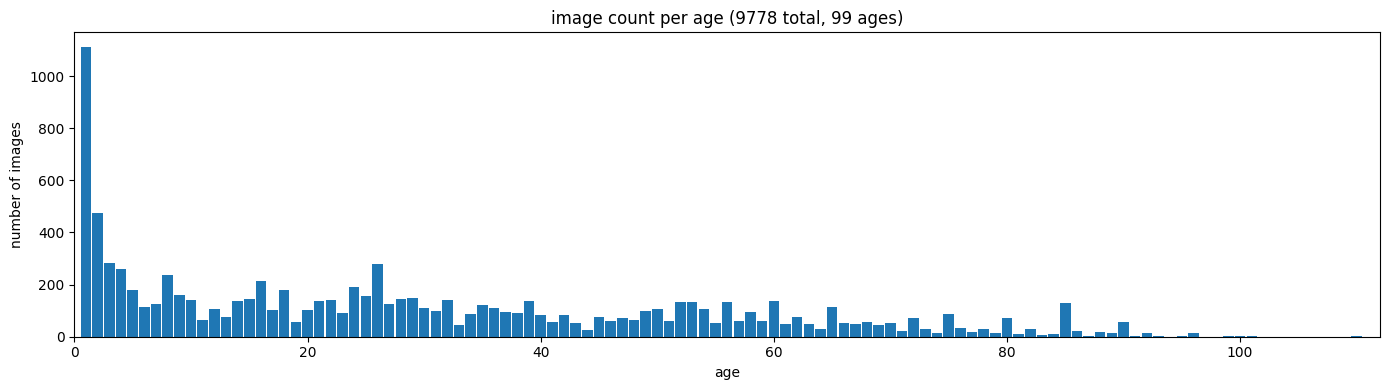

top 10 most-represented ages:
age
1     1112
2      475
3      284
26     279
4      260
8      236
16     212
24     191
18     181
5      180
Name: count, dtype: int64

bottom 10 least-represented ages:
age
91      1
101     1
110     2
100     2
99      2
95      3
93      3
87      4
83      7
81     10
Name: count, dtype: int64


In [ ]:
# count images per age, sorted so the plot is in age order not by frequency
counts = df["age"].value_counts().sort_index()

# bar chart — width=0.9 leaves a tiny gap so individual bars are visible
fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(counts.index, counts.values, width=0.9)
ax.set_xlabel("age")
ax.set_ylabel("number of images")
ax.set_title(f"image count per age ({len(df)} total, {df['age'].nunique()} ages)")
ax.set_xlim(0, 112)  # force x-axis to cover full possible range so gaps are visible
plt.tight_layout()
plt.show()

# numbers behind the plot — useful for the report
print("top 10 most-represented ages:")
print(counts.sort_values(ascending=False).head(10))
print("\nbottom 10 least-represented ages:")
print(counts.sort_values().head(10))

## 6. Brief's suggested categories

The brief proposes six bins: child 0–12, teen 13–19, youth 20–30, mid 31–45, mature 46–60, older 61+. Let's see how they map to our data.

age_category
child     3255
teen       909
youth     1626
mid       1306
mature    2682
Name: count, dtype: int64

total: 9778


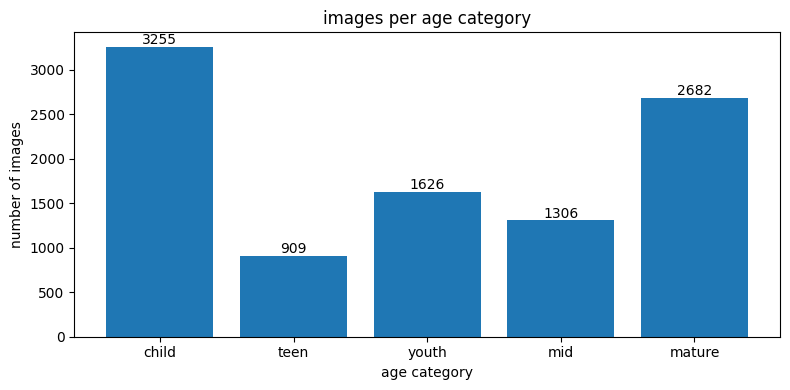

In [ ]:
# bin edges — right-exclusive intervals: [0,13), [13,20), [20,31), [31,46), [46, inf)
# matches the brief's suggested ranges, with mature+older merged into one bin
bins = [0, 13, 20, 31, 46, 200]
labels = ["child", "teen", "youth", "mid", "mature"]

# pd.cut maps each age to its bin label — right=False makes bins left-inclusive
df["age_category"] = pd.cut(df["age"], bins=bins, labels=labels, right=False)

# check how balanced (or not) the classes are
cat_counts = df["age_category"].value_counts().reindex(labels)
print(cat_counts)
print(f"\ntotal: {cat_counts.sum()}")

# bar chart of category sizes — quick visual of class imbalance
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(cat_counts.index, cat_counts.values)
ax.set_xlabel("age category")
ax.set_ylabel("number of images")
ax.set_title("images per age category")

# annotate bars with counts so the imbalance is immediately readable
for i, v in enumerate(cat_counts.values):
    ax.text(i, v + 30, str(v), ha="center")

plt.tight_layout()
plt.show()

## 7. Adjusted categories

Three changes to the recommended distribution:

1. Split `child` into `infant 0–4` + `child 5–12` (age 1 alone has 1112 images).
2. Split `mature` back out: `mature 46–60` + `senior 61+`.
3. `infant` stays as a deliberate outlier — it dominates because that's what the data actually looks like, and the model will benefit from learning that range explicitly.

We should see a more balanced distribution division

age_category
infant    2131
child     1124
teen       909
youth     1626
mid       1306
mature    1369
senior    1313
Name: count, dtype: int64


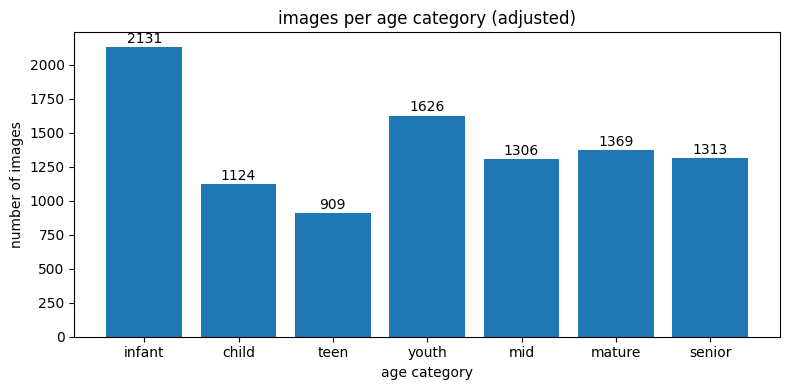

In [ ]:
# our final bins — 7 categories, split child into infant+child, split mature into mature+senior
bins = [0, 5, 13, 20, 31, 46, 61, 200]
labels = ["infant", "child", "teen", "youth", "mid", "mature", "senior"]

df["age_category"] = pd.cut(df["age"], bins=bins, labels=labels, right=False)

print(cat_counts)
# visualise the final categories
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(cat_counts.index, cat_counts.values)
ax.set_xlabel("age category")
ax.set_ylabel("number of images")
ax.set_title("images per age category (adjusted)")

# annotate bars with counts
for i, v in enumerate(cat_counts.values):
    ax.text(i, v + 30, str(v), ha="center")

plt.tight_layout()
plt.show()

## 8. Image sanity

Three checks on the actual files. Can every image be opened, what are the dimensions and how many channels.

In [ ]:
# walk every image, record size + mode, catch any that fail to open
# this is slow-ish (9778 files) but only runs once
sizes = []
modes = []
broken = []

for p in df["path"]:
    try:
        with Image.open(p) as im:
            sizes.append(im.size)   # (width, height)
            modes.append(im.mode)   # "RGB", "L", "RGBA", etc
    except Exception as e:
        broken.append((p, str(e)))

print(f"opened ok  {len(sizes)} / {len(df)}")
print(f"broken     {len(broken)}")
if broken:
    print("first few broken files:")
    for b in broken[:5]:
        print(b)

opened ok  9778 / 9778
broken     0


In [ ]:
# distribution of image sizes and colour modes
size_counts = Counter(sizes)
mode_counts = Counter(modes)

print("colour modes")
print(mode_counts)
print("\nunique sizes")
print(len(size_counts), "different sizes")
print("\ntop 5 sizes")
for sz, c in size_counts.most_common(5):
    print(f"  {sz} \t {c} images")

colour modes
Counter({'RGB': 9778})

unique sizes
1 different sizes

top 5 sizes
  (200, 200) 	 9778 images


## 9. Sample images per category

Sanity check the labels by eye. One sample per category, picked from the middle of each age range so it represents the bin well.

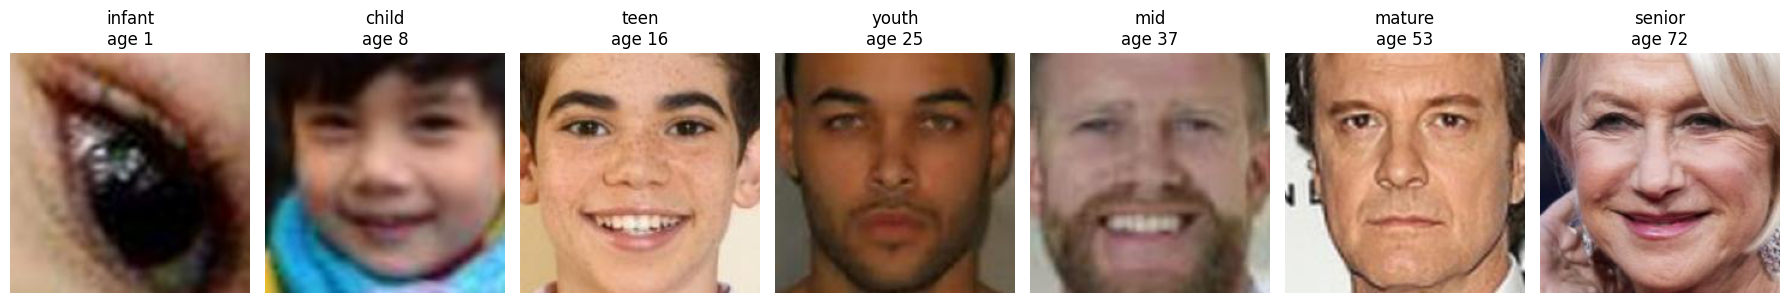

In [ ]:
# pick one representative image per category
# sort by age within each category, take the middle one so we get a "typical" example
fig, axes = plt.subplots(1, len(labels), figsize=(18, 4))

for ax, cat in zip(axes, labels):
    subset = df[df["age_category"] == cat].sort_values("age")
    middle = subset.iloc[len(subset) // 2]

    im = Image.open(middle["path"])
    ax.imshow(im)
    ax.set_title(f"{cat}\nage {middle['age']}")
    ax.axis("off")

plt.tight_layout()
plt.show()